In [ ]:
import pandas as pd

data = pd.read_csv('real_estate_data.csv', sep='\t')

In [ ]:
data.isna().sum()

,0
total_images,0
last_price,0
total_area,0
first_day_exposition,0
rooms,0
ceiling_height,9195
floors_total,86
living_area,1903
floor,0
is_apartment,20924


In [ ]:
data['balcony'] = data['balcony'].fillna(0)
data['is_apartment'] = data['is_apartment'].fillna(False)
data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].median())

/tmp/ipykernel_424/1096533282.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['is_apartment'] = data['is_apartment'].fillna(False)


In [ ]:
data['balcony'] = data['balcony'].astype(int)
data['floors_total'] = data['floors_total'].astype('Int64')
data['airports_nearest'] = data['airports_nearest'].astype('Int64')
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')
data['last_price'] = data['last_price'].astype(int)
data['cityCenters_nearest'] = data['cityCenters_nearest'].astype('Int64')
data['is_apartment'] = data['is_apartment'].astype('boolean')

In [ ]:
data.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000,108.0,2019-03-07,3,2.70,16,51.0,8,False,...,25.0,0,Санкт-Петербург,18863,16028,1.0,482.0,2.0,755.0,NaN
1,7,3350000,40.4,2018-12-04,1,2.65,11,18.6,1,False,...,11.0,2,посёлок Шушары,12817,18603,0.0,NaN,0.0,NaN,81.0
2,10,5196000,56.0,2015-08-20,2,2.65,5,34.3,4,False,...,8.3,0,Санкт-Петербург,21741,13933,1.0,90.0,2.0,574.0,558.0
3,0,64900000,159.0,2015-07-24,3,2.65,14,NaN,9,False,...,NaN,0,Санкт-Петербург,28098,6800,2.0,84.0,3.0,234.0,424.0
4,2,10000000,100.0,2018-06-19,2,3.03,14,32.0,13,False,...,41.0,0,Санкт-Петербург,31856,8098,2.0,112.0,1.0,48.0,121.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  int64         
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        23699 non-null  float64       
 6   floors_total          23613 non-null  Int64         
 7   living_area           21796 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  boolean       
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          21421 non-null  float64       
 13  balcony         

In [ ]:
data['price_per_m2'] = data['last_price'] / data['total_area']

In [ ]:
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_m2
0,20,13000000,108.00,2019-03-07,3,2.70,16,51.00,8,False,...,0,Санкт-Петербург,18863,16028,1.0,482.0,2.0,755.0,NaN,120370.370370
1,7,3350000,40.40,2018-12-04,1,2.65,11,18.60,1,False,...,2,посёлок Шушары,12817,18603,0.0,NaN,0.0,NaN,81.0,82920.792079
2,10,5196000,56.00,2015-08-20,2,2.65,5,34.30,4,False,...,0,Санкт-Петербург,21741,13933,1.0,90.0,2.0,574.0,558.0,92785.714286
3,0,64900000,159.00,2015-07-24,3,2.65,14,NaN,9,False,...,0,Санкт-Петербург,28098,6800,2.0,84.0,3.0,234.0,424.0,408176.100629
4,2,10000000,100.00,2018-06-19,2,3.03,14,32.00,13,False,...,0,Санкт-Петербург,31856,8098,2.0,112.0,1.0,48.0,121.0,100000.000000
5,10,2890000,30.40,2018-09-10,1,2.65,12,14.40,5,False,...,0,городской посёлок Янино-1,<NA>,<NA>,NaN,NaN,NaN,NaN,55.0,95065.789474
6,6,3700000,37.30,2017-11-02,1,2.65,26,10.60,6,False,...,1,посёлок Парголово,52996,19143,0.0,NaN,0.0,NaN,155.0,99195.710456
7,5,7915000,71.60,2019-04-18,2,2.65,24,NaN,22,False,...,2,Санкт-Петербург,23982,11634,0.0,NaN,0.0,NaN,NaN,110544.692737
8,20,2900000,33.16,2018-05-23,1,2.65,27,15.43,26,False,...,0,посёлок Мурино,<NA>,<NA>,NaN,NaN,NaN,NaN,189.0,87454.764777
9,18,5400000,61.00,2017-02-26,3,2.50,9,43.60,7,False,...,2,Санкт-Петербург,50898,15008,0.0,NaN,0.0,NaN,289.0,88524.590164


In [ ]:
data['floor_type'] = 'другой'
data['floor_type'] = data['floor_type'].where(data['floor'] != 1, 'первый')
data['floor_type'] = data['floor_type'].where(data['floor'] != data['floors_total'], 'последний')


In [ ]:
data['living_total'] = data['living_area'] / data['total_area']
data['kitchen_total'] = data['kitchen_area'] / data['total_area']

#EDA

<Axes: ylabel='Frequency'>

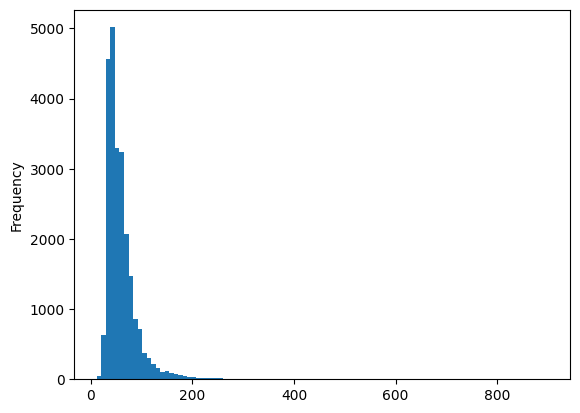

In [ ]:
data['total_area'].plot(kind='hist', bins=100)

In [ ]:
data['total_area'].describe()

,total_area
count,23699.000000
mean,60.348651
std,35.654083
min,12.000000
25%,40.000000
50%,52.000000
75%,69.900000
max,900.000000


<Axes: ylabel='Frequency'>

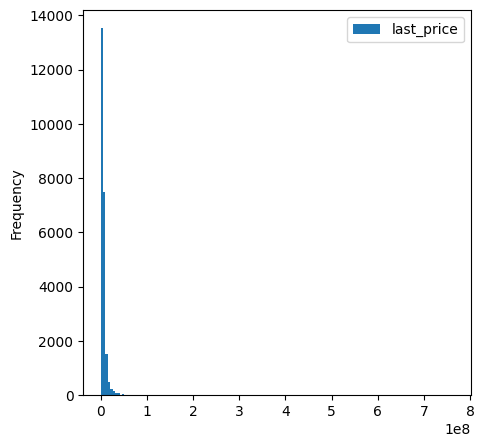

In [ ]:
data.plot(kind='hist', y='last_price', bins=150, figsize=(5,5))

In [ ]:
data['last_price'].describe()

,last_price
count,2.369900e+04
mean,6.541549e+06
std,1.088701e+07
min,1.219000e+04
25%,3.400000e+06
50%,4.650000e+06
75%,6.800000e+06
max,7.630000e+08


<Axes: ylabel='Frequency'>

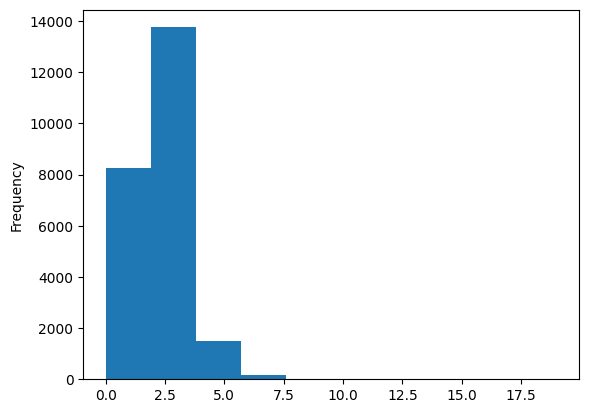

In [ ]:
data['rooms'].plot(kind='hist', bins=10)

In [ ]:
data['rooms'].describe()

,rooms
count,23699.000000
mean,2.070636
std,1.078405
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,19.000000


<Axes: ylabel='Frequency'>

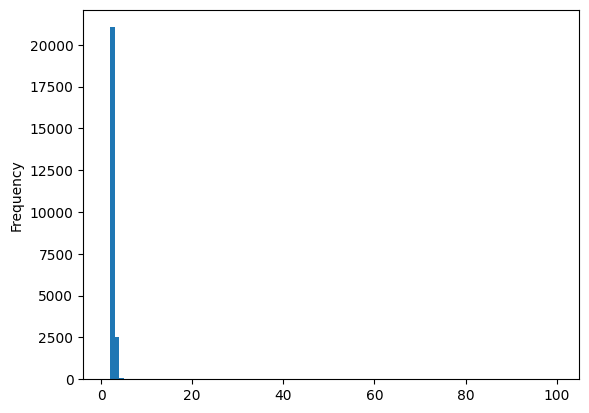

In [ ]:
data['ceiling_height'].plot(kind='hist', bins=100)

In [ ]:
data['ceiling_height'].describe()

,ceiling_height
count,23699.000000
mean,2.724358
std,0.988298
min,1.000000
25%,2.600000
50%,2.650000
75%,2.700000
max,100.000000


<Axes: ylabel='Frequency'>

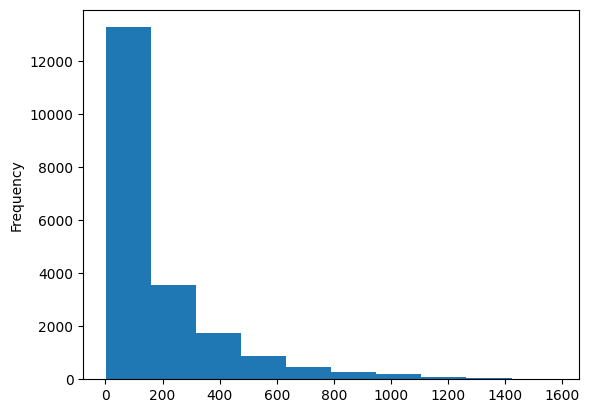

In [ ]:
data['days_exposition'].plot(kind='hist')

In [ ]:
exposition_mean = data['days_exposition'].mean()
exposition_median = data['days_exposition'].median()

print(exposition_mean)
print(exposition_median)

180.88863436982163
95.0


In [ ]:
data['days_exposition'].describe()

,days_exposition
count,20518.000000
mean,180.888634
std,219.727988
min,1.000000
25%,45.000000
50%,95.000000
75%,232.000000
max,1580.000000


In [ ]:
iqr = data['days_exposition'].quantile(0.75) - data['days_exposition'].quantile(0.25)
limit = data['days_exposition'].quantile(0.75) + 1.5 * iqr

data = data.query('days_exposition <= 512')
data['days_exposition'].describe()

,days_exposition
count,18849.000000
mean,128.753886
std,121.531193
min,1.000000
25%,41.000000
50%,85.000000
75%,183.000000
max,512.000000


In [ ]:
top10 = data['locality_name'].value_counts().head(10)
top10_data = data[data['locality_name'].isin(top10.index)]
top10_mean = top10_data.groupby('locality_name')['price_per_m2'].mean()
top10_mean.sort_values()

,price_per_m2
locality_name,
Выборг,57011.264060
Гатчина,68065.179716
Всеволожск,68605.620450
Колпино,74748.675396
посёлок Шушары,77914.528090
посёлок Мурино,86047.604034
посёлок Парголово,89162.888160
деревня Кудрово,92670.928672
Пушкин,101894.611356


/tmp/ipykernel_424/2309256852.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spb['cityCenters_nearest'] = (spb['cityCenters_nearest'] / 1000).round()


<Axes: xlabel='cityCenters_nearest'>

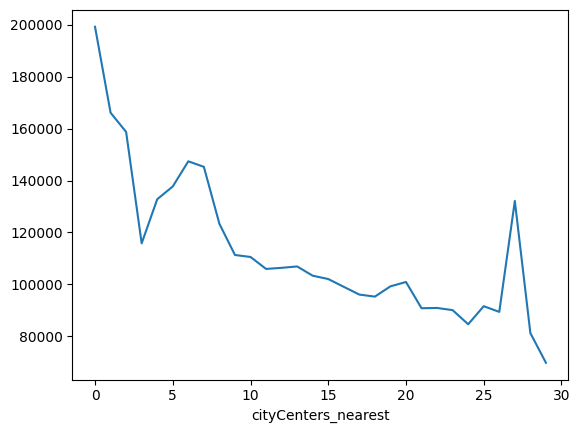

In [ ]:
spb = data.query('locality_name == "Санкт-Петербург"')
spb['cityCenters_nearest'] = (spb['cityCenters_nearest'] / 1000).round()
mean_km = spb.groupby('cityCenters_nearest')['price_per_m2'].mean()
mean_km.plot()
# центр - территория в радиусе ~7 км

In [ ]:
center = spb.query('cityCenters_nearest <= 7')

/tmp/ipykernel_424/1228990633.py:1: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  center = spb.query('cityCenters_nearest <= 7')


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_m2,floor_type,living_total,kitchen_total
3,0,64900000,159.0,2015-07-24,3,2.65,14,NaN,9,False,...,7.0,2.0,84.0,3.0,234.0,424.0,408176.100629,другой,NaN,NaN
24,8,6500000,97.2,2015-10-31,2,2.65,3,46.5,1,False,...,2.0,3.0,411.0,3.0,124.0,265.0,66872.427984,первый,0.478395,0.201646
63,2,20000000,118.0,2018-09-11,3,3.00,9,68.0,7,False,...,5.0,1.0,648.0,1.0,779.0,37.0,169491.525424,другой,0.576271,0.135593
94,3,3500000,29.5,2019-04-26,1,2.50,5,15.6,2,False,...,7.0,0.0,NaN,0.0,NaN,4.0,118644.067797,другой,0.528814,0.186441
99,32,9600000,90.0,2017-09-26,4,2.65,5,67.0,2,False,...,3.0,0.0,NaN,0.0,NaN,104.0,106666.666667,другой,0.744444,0.088889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23632,20,5000000,38.0,2018-06-23,1,2.55,16,NaN,15,False,...,7.0,1.0,241.0,1.0,230.0,113.0,131578.947368,другой,NaN,NaN
23644,7,4990000,62.5,2018-04-26,2,2.70,4,32.3,4,False,...,4.0,1.0,560.0,1.0,171.0,166.0,79840.000000,последний,0.516800,0.193600
23665,11,4250000,47.0,2016-05-20,1,2.65,6,18.2,1,False,...,5.0,2.0,624.0,1.0,519.0,131.0,90425.531915,первый,0.387234,0.310638
23681,13,5250000,43.0,2018-05-11,2,2.50,5,29.0,2,False,...,7.0,1.0,497.0,2.0,660.0,80.0,122093.023256,другой,0.674419,0.139535


count    2519.000000
mean       88.284899
std        56.826629
min        12.000000
25%        53.950000
50%        75.000000
75%       102.650000
max       618.000000
Name: total_area, dtype: float64


<Axes: >

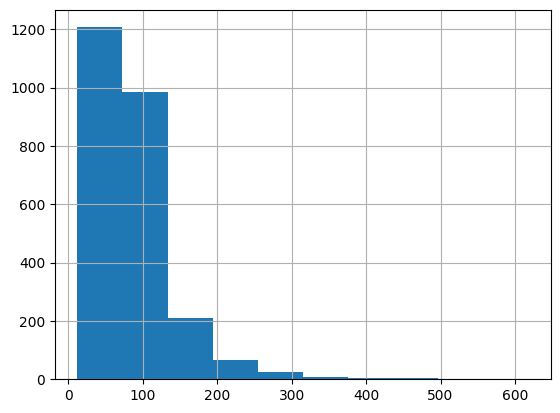

In [ ]:
print(center['total_area'].describe())
center['total_area'].hist()

count    2.519000e+03
mean     1.391489e+07
std      2.560099e+07
min      1.600000e+06
25%      6.300000e+06
50%      8.500000e+06
75%      1.299950e+07
max      7.630000e+08
Name: last_price, dtype: float64


<Axes: ylabel='Frequency'>

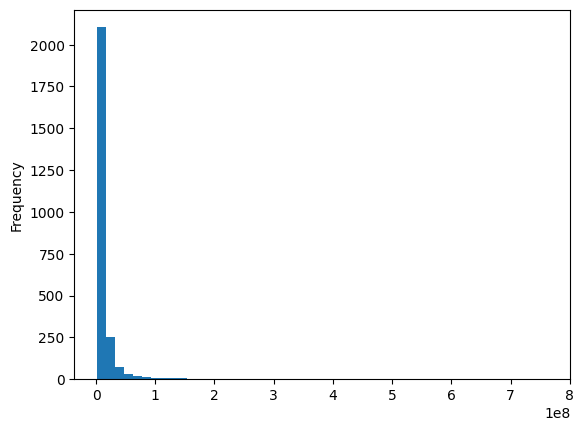

In [ ]:
print(center['last_price'].describe())
center['last_price'].plot(kind='hist', bins=50)

count    2519.000000
mean        2.726876
std         1.403232
min         0.000000
25%         2.000000
50%         3.000000
75%         3.000000
max        19.000000
Name: rooms, dtype: float64


<Axes: ylabel='Frequency'>

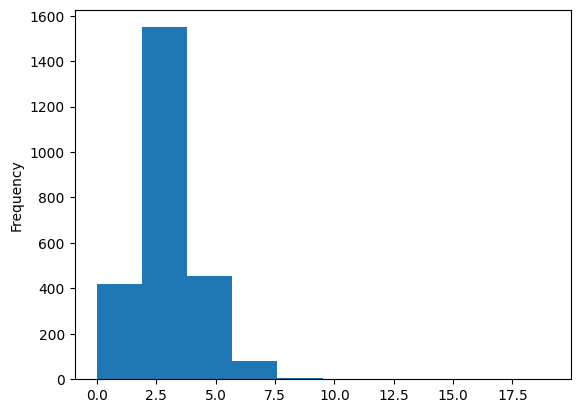

In [ ]:
print(center['rooms'].describe())
center['rooms'].plot(kind='hist')

count    2519.000000
mean        2.916911
std         0.598439
min         2.400000
25%         2.650000
50%         2.750000
75%         3.100000
max        27.000000
Name: ceiling_height, dtype: float64


<Axes: ylabel='Frequency'>

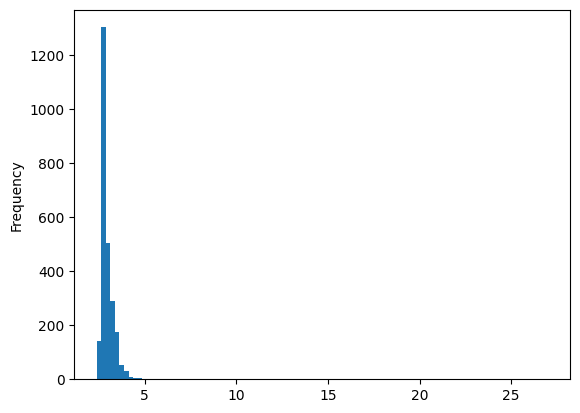

In [ ]:
print(center['ceiling_height'].describe())
center['ceiling_height'].plot(kind='hist', bins=100)

In [ ]:
center

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_m2,floor_type,living_total,kitchen_total
3,0,64900000,159.0,2015-07-24,3,2.65,14,NaN,9,False,...,7.0,2.0,84.0,3.0,234.0,424.0,408176.100629,другой,NaN,NaN
24,8,6500000,97.2,2015-10-31,2,2.65,3,46.5,1,False,...,2.0,3.0,411.0,3.0,124.0,265.0,66872.427984,первый,0.478395,0.201646
63,2,20000000,118.0,2018-09-11,3,3.00,9,68.0,7,False,...,5.0,1.0,648.0,1.0,779.0,37.0,169491.525424,другой,0.576271,0.135593
94,3,3500000,29.5,2019-04-26,1,2.50,5,15.6,2,False,...,7.0,0.0,NaN,0.0,NaN,4.0,118644.067797,другой,0.528814,0.186441
99,32,9600000,90.0,2017-09-26,4,2.65,5,67.0,2,False,...,3.0,0.0,NaN,0.0,NaN,104.0,106666.666667,другой,0.744444,0.088889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23632,20,5000000,38.0,2018-06-23,1,2.55,16,NaN,15,False,...,7.0,1.0,241.0,1.0,230.0,113.0,131578.947368,другой,NaN,NaN
23644,7,4990000,62.5,2018-04-26,2,2.70,4,32.3,4,False,...,4.0,1.0,560.0,1.0,171.0,166.0,79840.000000,последний,0.516800,0.193600
23665,11,4250000,47.0,2016-05-20,1,2.65,6,18.2,1,False,...,5.0,2.0,624.0,1.0,519.0,131.0,90425.531915,первый,0.387234,0.310638
23681,13,5250000,43.0,2018-05-11,2,2.50,5,29.0,2,False,...,7.0,1.0,497.0,2.0,660.0,80.0,122093.023256,другой,0.674419,0.139535
